# Lab 13: Generative Models

In this lab, we will have a look at two kinds of generative modeling frameworks: **variational autoencoders** (VAE) and **flow matching**. The VAE is a bit over 10 years old, making it "archaic" by today's standards. Flow matching, on the other hand, is much more recent and is behind the latest image and video generators, such as Google's Veo 3. It can be seen as a successor to diffusion models, which was the technology behind the first "boom" of realistic image generators, such as StableDiffusion. With the VAE, we will generate some MNIST samples, while we discuss how to arrange random 2d points into two "moons" with flow matching.

## Part 1: Variational Autoencoder (VAE)
The VAE [[1]](https://arxiv.org/abs/1312.6114) concerns itself with a particular kind of graphical model that consists of two variables connected by a single edge $\mathbf z \to \mathbf x$. Here, $\mathbf z$ is a _latent_ variable, while $\mathbf x$ is the _observed_ variable.

We are given a dataset $\mathbf X = \{\mathbf x^{(i)}\}_{i=1}^N$ that we assume to be generated by such a process. The process first draws a latent variable from a prior distribution $p_{\theta^*}(\mathbf z)$ and then samples the observed variable conditioned on the latent, using $p_{\theta^*}(\mathbf x \mid \mathbf z)$. Our aim is to sample from the data distribution $p_{\theta^*}(\mathbf x)$.
Even with access to $p_{\theta}(\mathbf z)$ and $p_{\theta}(\mathbf x \mid \mathbf z)$ for any $\theta$, we don't know the true parameters $\theta^*$, nor do we have access to the latent vectors $\mathbf z^{(i)}$ corresponding to the data points.

#### Question 1
Can the EM algorithm be used to solve this problem?

### <font color='green'><u>Solution</u></font>
No, because it requires us to sample from the posterior $p_{\theta^{(t)}}(\mathbf z \mid \mathbf x)$, which is not feasible in general.

<hr>

Since the true posterior for given parameters $\theta$ is generally intractable, we use *variational inference*, effectively approximating the true posterior $p_{\theta^*}(\mathbf z \mid \mathbf x)$ by $q_{\phi}(\mathbf z \mid \mathbf x)$. If $q$ is defined through a neural network, $\phi$ represents its weights and biases, which are referred to as the *variational parameters* in this context.

In a typical VAE, the following assumptions are made:
* The prior distribution over $\mathbf z$ is a standard (multivariate) normal: $p_{\theta}(\mathbf z) = \mathcal N(\mathbf z; \mathbf 0, \mathbf I)$.
* The variational posterior also follows a (multivariate) normal distribution $q_\phi(\mathbf z \mid \mathbf x) = \mathcal N(\mathbf z; \boldsymbol\mu, \mathsf{diag}(\boldsymbol\sigma^2))$ where $\boldsymbol\mu = \boldsymbol\mu_\phi(\mathbf x)$ and $\log \boldsymbol\sigma^2 = \log \boldsymbol\sigma_\phi(\mathbf x)^2$ are computed by a neural network. This component is called the **encoder**.
* Finally, $p_\theta(\mathbf x \mid \mathbf z)$ is assumed to be a Gaussian in the case of real data, or a Bernoulli distribution in the case of binary data. In either case, the distribution parameters are also computed by a neural network. This component is called the **decoder**.

### Training the VAE
For training, we want to maximize the log-likelihood of the data, as usual. Recall from the lecture that this is bounded from below by what we called the *ELBO*:
\begin{align*}
    \log p_\theta(\mathbf x) = \underbrace{\mathbb E_{q_\phi(\mathbf z \mid \mathbf x)}\left[\log \frac{p_\theta(\mathbf x, \mathbf z)}{q_\phi(\mathbf z \mid \mathbf x)}\right]}_{=: \mathcal L(\theta, \phi;\mathbf x)} + D_\mathrm{KL}(q_\phi(\mathbf z \mid \mathbf x) \Vert p_\theta(\mathbf z \mid \mathbf x)) \geq \mathcal L(\theta, \phi; \mathbf x).
\end{align*}
Before proceeding, we bring the ELBO into a different form.

#### Question 2 (*)
Show that $\mathcal L(\theta, \phi; \mathbf x) = \mathbb E_{q_\phi(\mathbf z \mid \mathbf x)}[\log p_\theta(\mathbf x \mid \mathbf z)] - D_\mathrm{KL}(q_\phi(\mathbf z \mid \mathbf x) \Vert p_\theta(\mathbf z))$. How can each term be interpreted?

### <font color='green'><u>Solution</u></font>

\begin{align*}
\mathcal L(\theta, \phi; \mathbf x)
= \mathbb E_{q_\phi(\mathbf z \mid \mathbf x)}\left[\log \frac{p_\theta(\mathbf x, \mathbf z)}{q_\phi(\mathbf z \mid \mathbf x)}\right]
= \mathbb E_{q_\phi(\mathbf z \mid \mathbf x)}\left[\log \frac{ p_\theta(\mathbf z) p_\theta(\mathbf x \mid \mathbf z)}{q_\phi(\mathbf z \mid \mathbf x)}\right]
= \mathbb E_{q_\phi(\mathbf z \mid \mathbf x)}\left[ \log p_\theta(\mathbf x \mid \mathbf z) \right] - \underbrace{\mathbb E_{q_\phi(\mathbf z \mid \mathbf x)}\left[ \log \frac{q_\phi(\mathbf z \mid \mathbf x)}{p_\theta(\mathbf z)} \right]}_{= D_\mathrm{KL}(q_\phi(\mathbf z \mid \mathbf x) \Vert p_\theta(\mathbf z))}.
\end{align*}

The first term is the expected log-likelihood of the observed data when drawing latents according to the variational posterior / encoder. The second term quantifies the distance between the variational posterior and the prior. In summary, the loss function forces the encoder-decoder architecture to maximize the log-likelihood of the data (-> reconstruction loss) while simultaneously keeping the latent distribution as close to the prior as possible (-> regularization term).

<hr>

To optimize the generative and variational parameters jointly, we use a variant of gradient descent on $\mathcal L$, such as Adam. If the prior and the encoder are Gaussians (as in our case), the second term can be differentiated analytically. For the first term, an estimate of the gradient is still necessary. To this end, the expectation is approximated via sampling, $\frac{1}{L} \sum_{\ell=1}^L \log p_\theta(\mathbf x \mid \mathbf z^{(\ell)})$, where $\mathbf z^{(\ell)} \sim q_\phi(\cdot \mid \mathbf x)$.

#### Question 3 (*)
Compute the gradient of the sampled expectation with respect to the generative parameters $\theta$. Why does the same approach not work for the variational parameters $\phi$? Propose a solution.

### <font color='green'><u>Solution</u></font>
For the generative parameters, we have
\begin{align*}
    \nabla_\theta \frac{1}{L} \sum_{\ell=1}^L \log p_\theta(\mathbf x \mid \mathbf z^{(\ell)}) = \frac{1}{L} \sum_{\ell=1}^L \nabla_\theta \log p_\theta(\mathbf x \mid \mathbf z^{(\ell)}).
\end{align*}
Repeating the same for the variational parameters, we find that $\nabla_\phi \frac{1}{L} \sum_{\ell=1}^L \log p_\theta(\mathbf x \mid \mathbf z^{(\ell)}) = 0$, since $p_\theta$ does not depend on $\phi$. But this is wrong. Notice how one of the inputs to $p_\theta$ is $\mathbf z^{(\ell)}$, which is drawn from $p_\phi(\mathbf z \mid \mathbf x)$ and therefore depends on $\phi$. A solution to this problem is the reparameterization trick. It depends on the distribution, but if $p_\phi$ is a Gaussian with diagonal covariance, we can instead draw $\boldsymbol\epsilon \sim \mathcal N(\mathbf 0, \mathbf I)$ and define $\mathbf z \coloneqq g_\phi(\boldsymbol\epsilon, \mathbf x) \coloneqq \boldsymbol\mu_\phi(\mathbf x) + \boldsymbol\epsilon \odot \boldsymbol\sigma_\phi(\mathbf x)$, where $\odot$ denotes the Hadamard (or elementwise) product. Then, we have
\begin{align*}
    \nabla_\phi \frac{1}{L} \sum_{\ell=1}^L \log p_\theta(\mathbf x \mid \mathbf z^{(\ell)}) = \frac{1}{L} \sum_{\ell=1}^L \nabla_\phi \log p_\theta(\mathbf x \mid g_\phi(\boldsymbol\epsilon^{(\ell)}, \mathbf x)),
\end{align*}
which is not always 0.

### Implementation
The following code is an implementation of a VAE. Make sure that you have `pytorch` and `torchvision` installed. Since we want to train on MNIST, which has pixel values in the interval $[0,1]$, we pick for the decoder a Bernoulli distribution.

In [8]:
import torch
import torch.nn as nn
from torch.distributions.multivariate_normal import MultivariateNormal
from torchvision import datasets, transforms
from tqdm import tqdm

class Encoder(nn.Module):
    def __init__(self, n_latent = 10):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU()
        )
        self.l_mu = nn.Linear(256, n_latent)
        self.l_var = nn.Linear(256, n_latent)

    def forward(self, x):
        x = self.fc(x)
        mu = self.l_mu(x)
        log_var = self.l_var(x)
        return mu, log_var

class Decoder(nn.Module):
    def __init__(self, n_latent = 10):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(n_latent, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU()
        )
        self.l_probs = nn.Linear(512, 784)
        

    def forward(self, z):
        z = self.fc(z)
        probs = torch.sigmoid(self.l_probs(z))
        return probs

def initialize_weights(model):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)

batch_size = 128
n_data = 784
n_latent = 10
encoder = Encoder(n_latent)
decoder = Decoder(n_latent)

initialize_weights(encoder)
initialize_weights(decoder)

#### Question 4 (*)
Implement the loss function $-\mathcal L(\theta, \phi, \mathbf x)$ with $L = 1$ Monte Carlo samples for the expectation. For the KL divergence term, you may use the fact that $$D_\mathrm{KL}(\mathcal N(\;\cdot\;; \boldsymbol \mu, \mathsf{diag}(\boldsymbol\sigma^2)) \Vert \mathcal N(\;\cdot\;; \mathbf 0, \mathbf I)) = \frac{1}{2} \sum_{j=1}^J (1 + \log((\sigma_j)^2) - (\mu_j)^2 - (\sigma_j)^2) + C,$$
where $J$ is the latent dimension and $C$ is a constant.

### <font color='green'><u>Solution</u></font>

In [9]:
def loss_fn(x, x_rec, mu_z, log_var_z):
    rec_loss = -nn.functional.binary_cross_entropy(x_rec, x, reduction='sum')

    # KL divergence to standard normal prior
    kl = -0.5 * (1 + log_var_z - mu_z.pow(2) - log_var_z.exp()).sum(axis=-1)
    
    return -(rec_loss - kl).sum()

### Training on MNIST
We will train the VAE on the MNIST handwritten digits dataset. You do not have to add any code, but make sure to have a look at the components going into the loss function. 

In [10]:
train_dataset = datasets.MNIST(root='./mnist_data/', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.MNIST(root='./mnist_data/', train=False, transform=transforms.ToTensor(), download=False)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

optimizer = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

In [11]:
def train(n_epochs=100):
    for epoch in tqdm(range(n_epochs)):
        train_loss = 0
        for batch_idx, (x, _) in enumerate(train_loader):
            # Flatten the image
            x = x.view(-1, n_data)

            # Reset gradients
            optimizer.zero_grad()

            # Encode and use reparameterization trick
            mu_z, log_var_z = encoder(x)
            std_z = torch.exp(0.5 * log_var_z)
            eps = torch.randn_like(std_z)
            z = mu_z + eps * std_z

            # Reconstruct
            x_rec = decoder(z)

            # Compute loss
            loss = loss_fn(x, x_rec, mu_z, log_var_z)

            # Backpropagation and weight update
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        print(f"Epoch {epoch+1}: Train loss: {train_loss / len(train_loader.dataset)}")
        scheduler.step(train_loss)

train(50)

  2%|▉                                           | 1/50 [00:04<03:34,  4.38s/it]

Epoch 1: Train loss: 17246.59586354167


  4%|█▊                                          | 2/50 [00:08<03:25,  4.29s/it]

Epoch 2: Train loss: 12025.967552083333


  6%|██▋                                         | 3/50 [00:12<03:23,  4.33s/it]

...

Epoch 48: Train loss: 9099.952133333334


 98%|██████████████████████████████████████████▏| 49/50 [03:38<00:04,  4.40s/it]

Epoch 49: Train loss: 9093.367377083334


100%|███████████████████████████████████████████| 50/50 [03:43<00:00,  4.46s/it]

Epoch 50: Train loss: 9080.569709375


#### Question 5
Write a function `sample` that samples a batch of images from the VAE.

### <font color='green'><u>Solution</u></font>
Sampling using a VAE is very easy, since we just have to sample a random latent variable and send it through the decoder.

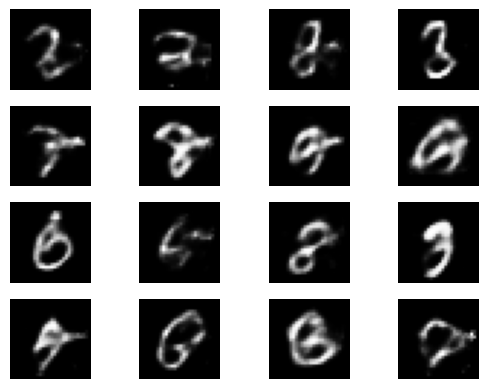

In [12]:
import matplotlib.pyplot as plt

def sample(n_samples=16):
    z = torch.randn((n_samples,n_latent))
    x = decoder(z)
    return x.reshape(n_samples, 28, 28).detach().numpy()

s = sample()
fig, ax = plt.subplots(4, 4)
for r in range(4):
    for c in range(4):
        ax[r][c].axis('off')
        ax[r][c].imshow(1-s[r*4+c], cmap='Greys')

### Conditional Sampling
Most of the time, we are not interested in generating arbitrary images from a dataset, but rather ones that belong to a certain *class* or, even more generally, match a certain description. This is called conditional or guided sampling. Assuming that images belonging to the same class lie close together in the latent space, all it takes it to find the regions in the latent space that belong to the different classes.

#### Question 6 (optional)
Pick a number $c \in \{0,\dots,9\}$, take a batch $\{\mathbf x^{(i)}\}_{i=1}^B$ of test images with label $c$ and compute the mean encoding vector $\boldsymbol\mu_c = \frac{1}{B} \sum_{i=1}^B \boldsymbol\mu_\phi(\mathbf x^{(i)})$. Then, generate samples by sampling latent vectors from $\mathcal N(\boldsymbol\mu_c, \mathbf I)$ instead of the standard normal distribution.

While this is a quick method, it only works if same-class data points actually form clusters in the latent space. Some other options include:
* Conditional VAE: Training the encoder and decoder with $[\mathbf x, \mathbf c]$ resp. $[\mathbf z, \mathbf c]$, where $\mathbf c$ is the one-hot encoded class vector and $[\cdot,\cdot]$ denotes vector concatenation.
* Classifier-Guided Sampling: For this, you can re-use the trained VAE, but you need to train an MNIST classifier $f = (f_0,\dots,f_9) \colon [0,1]^{28\times 28} \to [0,1]^{10}$. Then, use SGD to adjust $\mathbf z$ to maximize $f_c(\mathbf x)$, where $\mathbf x \sim p_\theta(\mathbf x \mid \mathbf z)$.
* Circling back to the method proposed in Question 6, we could attempt to improve it by modifying the loss function to enforce clustering behavior in the latent space: Instead of modeling $p(\mathbf z)$ as a standard normal distribution, we could try choosing a GMM.

## References
[1] Diederik Kingma and Max Welling: [Auto-Encoding Variational Bayes](https://arxiv.org/pdf/1312.6114) (ICLR 2014) <br>
[2] Yaron Lipman et al.: [Flow Matching Guide and Code](https://arxiv.org/pdf/2412.06264)